# Этап 7. Финальный пайплайн

**Проект:** Рекомендации по замене блюд

Этот ноутбук объединяет все предыдущие этапы в единую систему:
- Загружает обученные модели и датасет
- Принимает блюдо + цель пользователя
- Определяет, нужна ли замена
- Если нужна — находит похожее подходящее блюдо
- Показывает подробное сравнение КБЖУ


## 1. Загрузка всех компонентов системы

In [22]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/russian_food_labeled.csv')

with open('../data/best_models.pkl', 'rb') as f:
    best_models = pickle.load(f)

with open('../data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']
label_to_target = dict(zip(labels, targets))

nutrition_features = [
    'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
    'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)'
]

print('Все компоненты системы загружены успешно')
print(f'Датасет: {len(df)} блюд, {df["Category"].nunique()} категорий')
print(f'Моделей: {len(best_models)}')
print()


MODEL_NAMES_RU = {
    'LogisticRegression': 'Логистическая регрессия',
    'DecisionTreeClassifier': 'Дерево решений',
    'RandomForestClassifier': 'Случайный лес',
    'GradientBoostingClassifier': 'Градиентный бустинг',
}

print('Лучшие модели по целям:')
for label in labels:
    model_class = type(best_models[label]).__name__
    print(f'  {label}: {MODEL_NAMES_RU.get(model_class, model_class)}')

Все компоненты системы загружены успешно
Датасет: 400 блюд, 17 категорий
Моделей: 4

Лучшие модели по целям:
  Похудение: Градиентный бустинг
  Набор массы: Градиентный бустинг
  Баланс/ЗОЖ: Градиентный бустинг
  Контроль сахара: Градиентный бустинг


## 2. Финальная функция рекомендации

In [23]:
def find_replacement_knn(dish, category, target_col):
    category_mask = (df['Category'] == category) & (df['Food_Item'] != dish['Food_Item'])
    df_cat = df[category_mask].reset_index(drop=True)

    if len(df_cat) < 2:
        return None, 'Недостаточно блюд в категории'

    scaler = StandardScaler()
    X_cat = scaler.fit_transform(df_cat[nutrition_features].astype(float))
    X_dish = scaler.transform(
        pd.DataFrame([dish[nutrition_features].astype(float)])[nutrition_features]
    )

    # Ранжируем ВСЕХ кандидатов категории по расстоянию, а не только первые k.
    knn = NearestNeighbors(n_neighbors=len(df_cat), metric='euclidean')
    knn.fit(X_cat)
    distances, indices = knn.kneighbors(X_dish)

    for idx in indices[0]:
        neighbor = df_cat.iloc[idx]
        if int(neighbor[target_col]) == 0:
            return neighbor, None

    return None, f'Среди {len(df_cat)} блюд категории замена не найдена'


def recommend(food_item, goal):
    target_col = label_to_target[goal]

    dish_rows = df[df['Food_Item'] == food_item]
    if len(dish_rows) == 0:
        available = df['Food_Item'].tolist()
        similar = [f for f in available if food_item.lower() in f.lower()]
        return {
            'status': 'error',
            'message': f'Блюдо "{food_item}" не найдено.',
            'similar': similar[:5] if similar else []
        }

    dish = dish_rows.iloc[0]
    category = dish['Category']
    needs_replacement = int(dish[target_col]) == 1
    original = {f: float(dish[f]) for f in nutrition_features}

    if not needs_replacement:
        return {
            'status': 'ok', 'food_item': food_item, 'goal': goal,
            'category': category, 'needs_replacement': False,
            'original': original,
            'message': 'Блюдо подходит для вашей цели!'
        }

    replacement, error_msg = find_replacement_knn(dish, category, target_col)

    if replacement is None:
        return {
            'status': 'no_replacement', 'food_item': food_item,
            'goal': goal, 'category': category, 'needs_replacement': True,
            'original': original, 'message': error_msg
        }

    replacement_values = {f: float(replacement[f]) for f in nutrition_features}
    return {
        'status': 'replaced', 'food_item': food_item, 'goal': goal,
        'category': category, 'needs_replacement': True,
        'original': original,
        'replacement': replacement['Food_Item'], 'replacement_values': replacement_values,
        'message': f'Рекомендуем заменить на "{replacement["Food_Item"]}"'
    }

## 3. Вывод результата

In [24]:
def print_recommendation(result):
    print('=' * 60)

    if result['status'] == 'error':
        print(f'Ошибка: {result["message"]}')
        if result.get('similar'):
            print('Похожие блюда в датасете:', result['similar'])
        print('=' * 60)
        return

    print(f'Блюдо:     {result["food_item"]} (на 100г)')
    print(f'Цель:      {result["goal"]}')
    print(f'Категория: {result["category"]}')
    print('-' * 60)

    if result['status'] == 'ok':
        print('Вердикт: Замена НЕ нужна')
        print(f'Комментарий: {result["message"]}')
        print()
        print('КБЖУ на 100г:')
        for k, v in result['original'].items():
            print(f'  {k:<25} {v}')

    elif result['status'] == 'no_replacement':
        print('Вердикт: Замена нужна, но не найдена')
        print(f'Причина: {result["message"]}')
        print()
        print('КБЖУ оригинала на 100г:')
        for k, v in result['original'].items():
            print(f'  {k:<25} {v}')

    elif result['status'] == 'replaced':
        print('Вердикт: Замена нужна')
        print(f'Рекомендация:  {result["replacement"]}')
        print()
        print('КБЖУ оригинала на 100г:')
        for k, v in result['original'].items():
            print(f'  {k:<25} {v}')
        print()
        print('КБЖУ замены на 100г:')
        for k, v in result['replacement_values'].items():
            print(f'  {k:<25} {v}')

    print('=' * 60)

## 4. Демонстрация системы

In [25]:

demo_cases = [
    ('Шоколадный торт',        'Похудение'),
    ('Борщ',                   'Набор массы'),
    ('Пельмени',               'Контроль сахара'),
    ('Сосиски варёные',        'Баланс/ЗОЖ'),
    ('Гречневая каша на воде', 'Похудение'),
    ('Медовик',                'Контроль сахара'),
]

for food, goal in demo_cases:
    result = recommend(food, goal)
    print_recommendation(result)
    print()

Блюдо:     Шоколадный торт (на 100г)
Цель:      Похудение
Категория: Десерт
------------------------------------------------------------
Вердикт: Замена нужна
Рекомендация:  Творожный пудинг

КБЖУ оригинала на 100г:
  Calories (kcal)           385.0
  Protein (g)               5.5
  Carbohydrates (g)         52.5
  Fat (g)                   18.5
  Fiber (g)                 1.5
  Sugars (g)                38.5
  Sodium (mg)               180.0

КБЖУ замены на 100г:
  Calories (kcal)           185.0
  Protein (g)               10.5
  Carbohydrates (g)         22.5
  Fat (g)                   6.0
  Fiber (g)                 0.3
  Sugars (g)                12.5
  Sodium (mg)               120.0

Блюдо:     Борщ (на 100г)
Цель:      Набор массы
Категория: Суп
------------------------------------------------------------
Вердикт: Замена нужна
Рекомендация:  Суп с клёцками

КБЖУ оригинала на 100г:
  Calories (kcal)           50.0
  Protein (g)               2.8
  Carbohydrates (g)         5.2


## 5. Визуализация сравнения

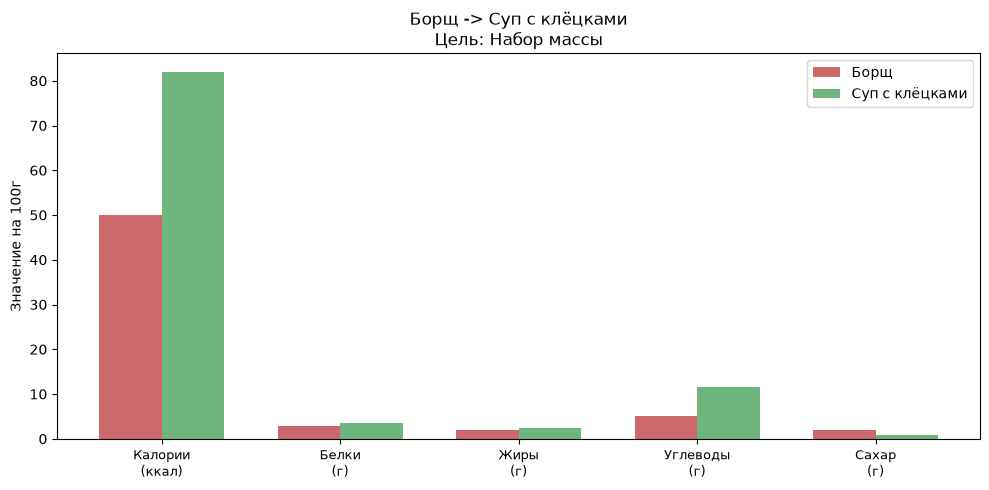

In [26]:
def visualize_recommendation(result):
    if result['status'] != 'replaced':
        print('Нет замены для визуализации')
        return

    features_show = ['Calories (kcal)', 'Protein (g)',
                     'Fat (g)', 'Carbohydrates (g)', 'Sugars (g)']
    short_names   = ['Калории\n(ккал)', 'Белки\n(г)',
                     'Жиры\n(г)', 'Углеводы\n(г)', 'Сахар\n(г)']

    orig_vals = [result['original'][f] for f in features_show]
    repl_vals = [result['replacement_values'][f] for f in features_show]

    x, width = np.arange(len(short_names)), 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, orig_vals, width,
           label=result['food_item'], color='#C44E52', alpha=0.85)
    ax.bar(x + width/2, repl_vals, width,
           label=result['replacement'], color='#55A868', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=9)
    ax.set_ylabel('Значение на 100г')
    ax.set_title(f'{result["food_item"]} -> {result["replacement"]}\nЦель: {result["goal"]}')
    ax.legend()
    plt.tight_layout()
    plt.show()

r1 = recommend('Борщ', 'Набор массы')
visualize_recommendation(r1)


## 6. Итоговая сводка по всему датасету

In [27]:

print('Статистика рекомендаций по всему датасету:')
print()
print(f'{"Цель":<20} {"Не нужна":>10} {"Нашли замену":>14} {"Не нашли":>10}')
print('-' * 57)

for goal in labels:
    ok = replaced = not_found = 0
    for _, row in df.iterrows():
        r = recommend(row['Food_Item'], goal)
        if r['status'] == 'ok':
            ok += 1
        elif r['status'] == 'replaced':
            replaced += 1
        else:
            not_found += 1
    total = ok + replaced + not_found
    print(f'{goal:<20} {ok:>8} ({ok/total*100:.0f}%) '
          f'{replaced:>10} ({replaced/total*100:.0f}%) '
          f'{not_found:>8} ({not_found/total*100:.0f}%)')

Статистика рекомендаций по всему датасету:

Цель                   Не нужна   Нашли замену   Не нашли
---------------------------------------------------------
Похудение                 226 (56%)        165 (41%)        9 (2%)
Набор массы               221 (55%)        179 (45%)        0 (0%)
Баланс/ЗОЖ                248 (62%)        152 (38%)        0 (0%)
Контроль сахара           262 (66%)        138 (34%)        0 (0%)
